# Refactored MAF Workflow Demo

## Purpose

The SKCM and COAD notebooks are written as transparent, step-by-step exploratory analyses so that readers can follow each line of code.

This notebook demonstrates how repeated MAF analysis steps can also be refactored into reusable helper functions stored in `src/maf_utils.py`.

This approach improves code reuse, maintainability, and consistency across cancer-type analyses while preserving the more detailed walkthrough notebooks for public readability.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Define project paths
project_dir = Path("..")
data_dir = project_dir / "data"
results_dir = project_dir / "results" / "refactored_demo"
src_dir = project_dir / "src"

# Create output folder for demo results
results_dir.mkdir(parents=True, exist_ok=True)

# Add src folder to Python path so we can import maf_utils.py
sys.path.append(str(src_dir))

data_dir, results_dir, src_dir

(WindowsPath('../data'),
 WindowsPath('../results/refactored_demo'),
 WindowsPath('../src'))

In [2]:
from maf_utils import (
    find_maf_files,
    load_maf_files,
    summarize_maf,
    mutation_classification_counts,
    variant_type_counts,
    top_mutated_genes,
    mutation_counts_per_sample,
    calculate_iqr_outlier_threshold,
    filter_genes_of_interest,
    summarize_genes_of_interest,
)

## Load SKCM MAF Files Using Helper Functions

The original SKCM notebook shows each loading step explicitly. Here, the same logic is condensed into reusable helper functions:

- `find_maf_files()` identifies downloaded `.maf.gz` files.
- `load_maf_files()` reads and concatenates the files into one dataframe.
- `summarize_maf()` returns basic dataset counts.

In [3]:
skcm_maf_dir = data_dir / "skcm_maf"

skcm_files = find_maf_files(skcm_maf_dir)

print(f"Found {len(skcm_files)} SKCM MAF files.")

Found 150 SKCM MAF files.


In [4]:
skcm_maf = load_maf_files(skcm_files)

print(
    f"Loaded combined SKCM MAF with "
    f"{skcm_maf.shape[0]:,} rows and {skcm_maf.shape[1]:,} columns."
)

Loaded combined SKCM MAF with 85,981 rows and 141 columns.


In [5]:
summarize_maf(skcm_maf)

{'n_variants': 85981, 'n_samples': 150, 'n_genes': 15176}

## Generate Reusable Summary Tables

The following cells use helper functions to generate common MAF summary outputs.

In [6]:
skcm_mutation_classes = mutation_classification_counts(skcm_maf)
skcm_mutation_classes

,Variant_Classification,Count
0,Missense_Mutation,50901
1,Silent,27899
2,Nonsense_Mutation,3154
3,Intron,833
4,Splice_Site,710
5,Splice_Region,698
6,RNA,638
7,Frame_Shift_Del,292
8,3'UTR,205
9,5'Flank,129


In [7]:
skcm_variant_types = variant_type_counts(skcm_maf)
skcm_variant_types

,Variant_Type,Count
0,SNP,85470
1,DEL,388
2,INS,119
3,ONP,2
4,TNP,2


In [8]:
skcm_top_genes = top_mutated_genes(skcm_maf, n=20)
skcm_top_genes

,Gene,Mutation_Count
0,TTN,701
1,MUC16,454
2,DNAH5,196
3,PCLO,164
4,LRP1B,119
5,DNAH7,105
6,DNAH9,104
7,ANK3,103
8,FAT4,102
9,MGAM,102


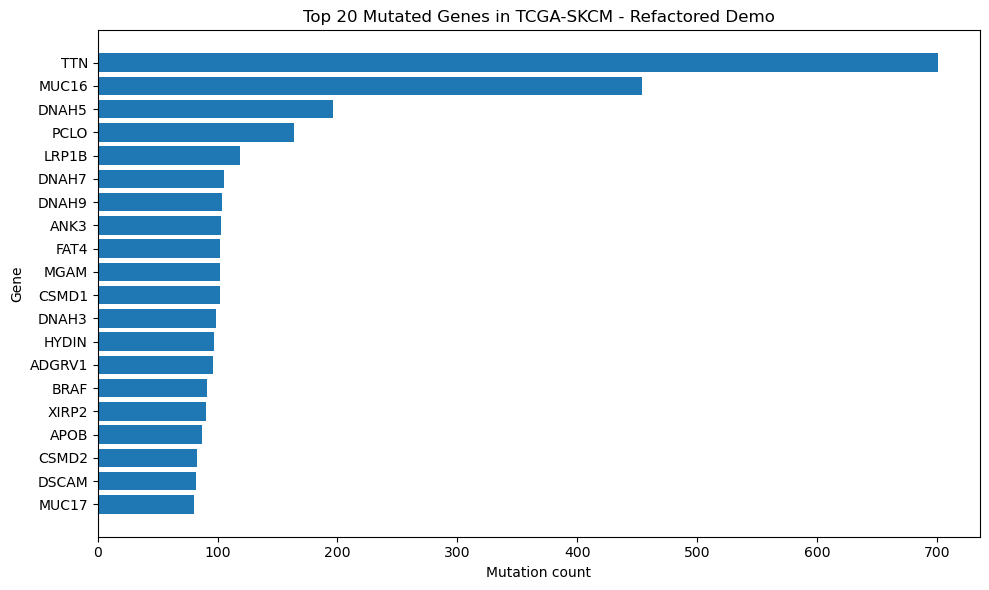

In [9]:
plt.figure(figsize=(10, 6))
plt.barh(skcm_top_genes["Gene"], skcm_top_genes["Mutation_Count"])
plt.gca().invert_yaxis()
plt.xlabel("Mutation count")
plt.ylabel("Gene")
plt.title("Top 20 Mutated Genes in TCGA-SKCM - Refactored Demo")
plt.tight_layout()
plt.savefig(results_dir / "refactored_demo_skcm_top_20_mutated_genes.png", dpi=300, bbox_inches="tight")
plt.show()

## Mutation Count Outlier Workflow

The same helper functions can be used to calculate mutation counts per sample and define an exploratory IQR-based high-mutation outlier threshold.

In [10]:
skcm_sample_counts = mutation_counts_per_sample(skcm_maf)
skcm_sample_counts.head()

,Tumor_Sample_Barcode,Mutation_Count
113,TCGA-FR-A726-01A-11D-A32N-08,8473
130,TCGA-GN-A266-06A-11D-A197-08,4657
149,TCGA-Z2-A8RT-06A-11D-A372-08,3507
94,TCGA-EE-A3J5-06A-11D-A20D-08,2584
87,TCGA-EE-A20C-06A-11D-A196-08,2516


In [11]:
threshold_info = calculate_iqr_outlier_threshold(skcm_sample_counts["Mutation_Count"])
threshold_info

{'q1': np.float64(101.0),
 'q3': np.float64(605.5),
 'iqr': np.float64(504.5),
 'threshold': np.float64(1362.25)}

In [12]:
skcm_outlier_samples = (
    skcm_sample_counts[
        skcm_sample_counts["Mutation_Count"] > threshold_info["threshold"]
    ]
    .copy()
    .sort_values("Mutation_Count", ascending=False)
)

skcm_outlier_samples.head(20)

,Tumor_Sample_Barcode,Mutation_Count
113,TCGA-FR-A726-01A-11D-A32N-08,8473
130,TCGA-GN-A266-06A-11D-A197-08,4657
149,TCGA-Z2-A8RT-06A-11D-A372-08,3507
94,TCGA-EE-A3J5-06A-11D-A20D-08,2584
87,TCGA-EE-A20C-06A-11D-A196-08,2516
148,TCGA-YG-AA3N-01A-11D-A38G-08,2442
47,TCGA-EB-A41A-01A-11D-A24R-08,2253
52,TCGA-EB-A431-01A-11D-A25O-08,2086
133,TCGA-GN-A26C-01A-11D-A19A-08,2060
23,TCGA-D3-A5GO-06A-12D-A27K-08,1889


## Genes-of-Interest Workflow

The helper functions can also filter and summarize a cancer-specific gene set.

In [13]:
skcm_genes_of_interest = [
    "BRAF", "NRAS", "NF1", "KIT",
    "TP53", "PTEN", "CDKN2A",
    "B2M", "JAK1", "JAK2"
]

skcm_goi_variants = filter_genes_of_interest(skcm_maf, skcm_genes_of_interest)
skcm_goi_variants.head()

,Hugo_Symbol,Chromosome,Start_Position,End_Position,Reference_Allele,Tumor_Seq_Allele2,Variant_Classification,Variant_Type,Tumor_Sample_Barcode,HGVSc,HGVSp_Short,Protein_position,t_depth,t_ref_count,t_alt_count,source_file,Tumor_VAF
138,BRAF,chr7,140753336,140753336,A,T,Missense_Mutation,SNP,TCGA-EB-A5SE-01A-11D-A30X-08,c.1919T>A,p.V640E,640/806,163,41,121,4ea04f40-1608-49e6-925a-985ab6f6e863.wxs.aliqu...,0.742331
546,BRAF,chr7,140753336,140753336,A,T,Missense_Mutation,SNP,TCGA-EB-A6R0-01A-12D-A32N-08,c.1919T>A,p.V640E,640/806,147,71,76,cde3c357-75fe-4f83-a1e8-a55c0dad563d.wxs.aliqu...,0.517007
547,BRAF,chr7,140753337,140753337,C,T,Missense_Mutation,SNP,TCGA-EB-A6R0-01A-12D-A32N-08,c.1918G>A,p.V640M,640/806,148,72,76,cde3c357-75fe-4f83-a1e8-a55c0dad563d.wxs.aliqu...,0.513514
594,PTEN,chr10,87957916,87957917,-,AC,Frame_Shift_Ins,INS,TCGA-EB-A6R0-01A-12D-A32N-08,c.699_700dup,p.R234Hfs*23,233/403,116,59,57,cde3c357-75fe-4f83-a1e8-a55c0dad563d.wxs.aliqu...,0.491379
2401,JAK2,chr9,5054784,5054784,C,T,Missense_Mutation,SNP,TCGA-Z2-A8RT-06A-11D-A372-08,c.836C>T,p.P279L,279/1132,57,18,39,fca6b0cb-c82f-47ee-ae92-7666680c66c8.wxs.aliqu...,0.684211


In [14]:
skcm_goi_summary = summarize_genes_of_interest(skcm_goi_variants)
skcm_goi_summary

,Hugo_Symbol,Variant_Count
1,BRAF,91
6,NF1,32
7,NRAS,31
9,TP53,22
2,CDKN2A,14
8,PTEN,13
5,KIT,7
3,JAK1,5
4,JAK2,4
0,B2M,2


In [15]:
skcm_mutation_classes.to_csv(results_dir / "refactored_demo_skcm_mutation_classification_counts.csv", index=False)
skcm_variant_types.to_csv(results_dir / "refactored_demo_skcm_variant_type_counts.csv", index=False)
skcm_top_genes.to_csv(results_dir / "refactored_demo_skcm_top_mutated_genes.csv", index=False)
skcm_sample_counts.to_csv(results_dir / "refactored_demo_skcm_mutation_counts_per_sample.csv", index=False)
skcm_outlier_samples.to_csv(results_dir / "refactored_demo_skcm_outlier_samples.csv", index=False)
skcm_goi_summary.to_csv(results_dir / "refactored_demo_skcm_genes_of_interest_summary.csv", index=False)

## Summary

This companion notebook demonstrates how repeated somatic MAF analysis steps can be organized into reusable Python helper functions.

The main SKCM and COAD notebooks remain fully expanded for readability and public transparency, while this notebook demonstrates a more modular workflow using `src/maf_utils.py`.

This structure separates:

- notebook-based analysis and interpretation
- reusable source code
- local data files
- exported result tables and figures